### Multivariate Linear Regression on Housing Price Prediction Dataset

In [131]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

In [132]:
## loading the dataset

data = pd.read_csv('/home/lucifer/Documents/Tech_Manthan/Day-4/dataset/housing_price_dataset.csv')
data.shape

(50000, 6)

In [133]:
data.head()

,SquareFeet,Bedrooms,Bathrooms,Neighborhood,YearBuilt,Price
0,2126,4,1,Rural,1969,215355.283618
1,2459,3,2,Rural,1980,195014.221626
2,1860,2,1,Suburb,1970,306891.012076
3,2294,2,1,Urban,1996,206786.787153
4,2130,5,2,Suburb,2001,272436.239065


In [134]:
## viewing the dataset statistics
data.describe(include='all')

,SquareFeet,Bedrooms,Bathrooms,Neighborhood,YearBuilt,Price
count,50000.000000,50000.000000,50000.000000,50000,50000.000000,50000.000000
unique,NaN,NaN,NaN,3,NaN,NaN
top,NaN,NaN,NaN,Suburb,NaN,NaN
freq,NaN,NaN,NaN,16721,NaN,NaN
mean,2006.374680,3.498700,1.995420,NaN,1985.404420,224827.325151
std,575.513241,1.116326,0.815851,NaN,20.719377,76141.842966
min,1000.000000,2.000000,1.000000,NaN,1950.000000,-36588.165397
25%,1513.000000,3.000000,1.000000,NaN,1967.000000,169955.860225
50%,2007.000000,3.000000,2.000000,NaN,1985.000000,225052.141166
75%,2506.000000,4.000000,3.000000,NaN,2003.000000,279373.630052


In [135]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   SquareFeet    50000 non-null  int64  
 1   Bedrooms      50000 non-null  int64  
 2   Bathrooms     50000 non-null  int64  
 3   Neighborhood  50000 non-null  object 
 4   YearBuilt     50000 non-null  int64  
 5   Price         50000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 2.3+ MB


In [136]:
data.isnull().sum()

SquareFeet      0
Bedrooms        0
Bathrooms       0
Neighborhood    0
YearBuilt       0
Price           0
dtype: int64

No null value in the dataset

In [137]:
data.duplicated().sum()

np.int64(0)

No duplicate value

In [138]:
## Checking if price are negative
negative_prices = data[data['Price'] < 0]
print("Number of negative price values:", negative_prices.shape[0])

Number of negative price values: 22


In [139]:
data = data[data['Price'] >= 0]
# data = data.reset_index(inplace=True)

In [171]:
data = data.reset_index(drop=True)
data

,SquareFeet,Bedrooms,Bathrooms,Neighborhood,YearBuilt,Price,Age
0,2126,4,1,Rural,1969,215355.283618,56
1,2459,3,2,Rural,1980,195014.221626,45
2,1860,2,1,Suburb,1970,306891.012076,55
3,2294,2,1,Urban,1996,206786.787153,29
4,2130,5,2,Suburb,2001,272436.239065,24
...,...,...,...,...,...,...,...
49973,1282,5,3,Rural,1975,100080.865895,50
49974,2854,2,2,Suburb,1988,374507.656727,37
49975,2979,5,3,Suburb,1962,384110.555590,63
49976,2596,5,2,Rural,1984,380512.685957,41


In [172]:
data['Neighborhood'].value_counts()

Neighborhood
Suburb    16716
Rural     16668
Urban     16594
Name: count, dtype: int64

In [173]:
data['Age'] = 2025 - data['YearBuilt']
data.shape

(49978, 7)

##### Visualizing Plots

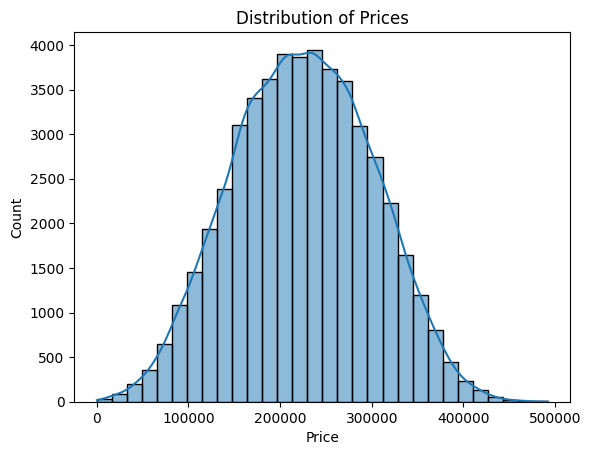

In [174]:
sns.histplot(data=data['Price'],bins=30,kde=True)
plt.title('Distribution of Prices')
plt.xlabel('Price')
plt.show()

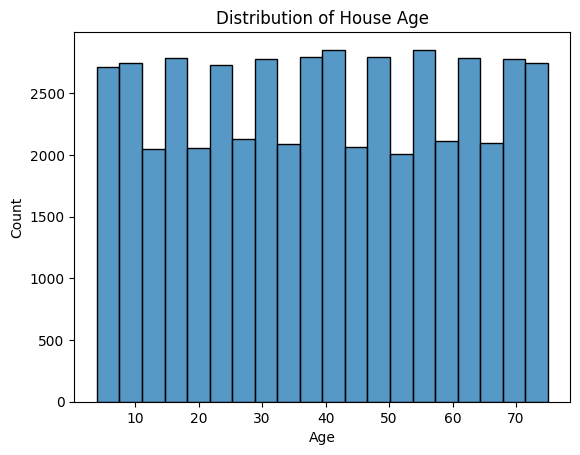

In [176]:
sns.histplot(data=data['Age'],bins=20)
plt.title('Distribution of House Age')
plt.xlabel('Age')
plt.show()

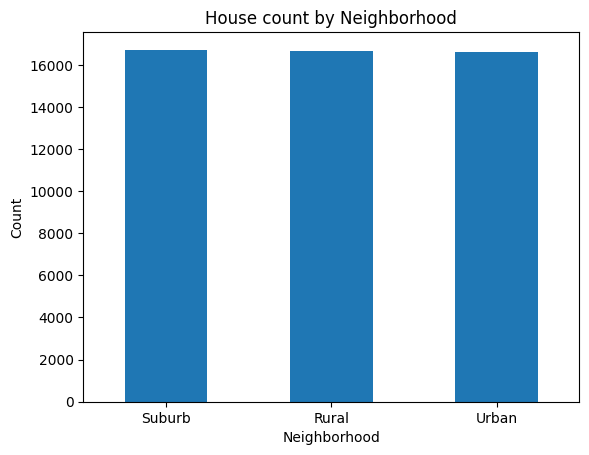

In [144]:
neighborhood_counts = data['Neighborhood'].value_counts()

neighborhood_counts.plot(kind='bar')
plt.title('House count by Neighborhood')
plt.xlabel('Neighborhood')
plt.ylabel('Count')
plt.xticks(rotation=360)
plt.show()

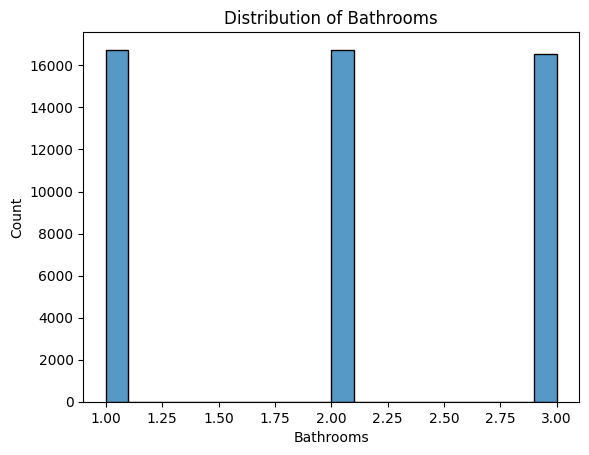

In [145]:
sns.histplot(data=data['Bathrooms'],bins=20)
plt.title('Distribution of Bathrooms')
plt.xlabel('Bathrooms')
plt.show()

Bivariate Analysis

In [146]:
data.columns

Index(['SquareFeet', 'Bedrooms', 'Bathrooms', 'Neighborhood', 'YearBuilt',
       'Price', 'Age'],
      dtype='object')

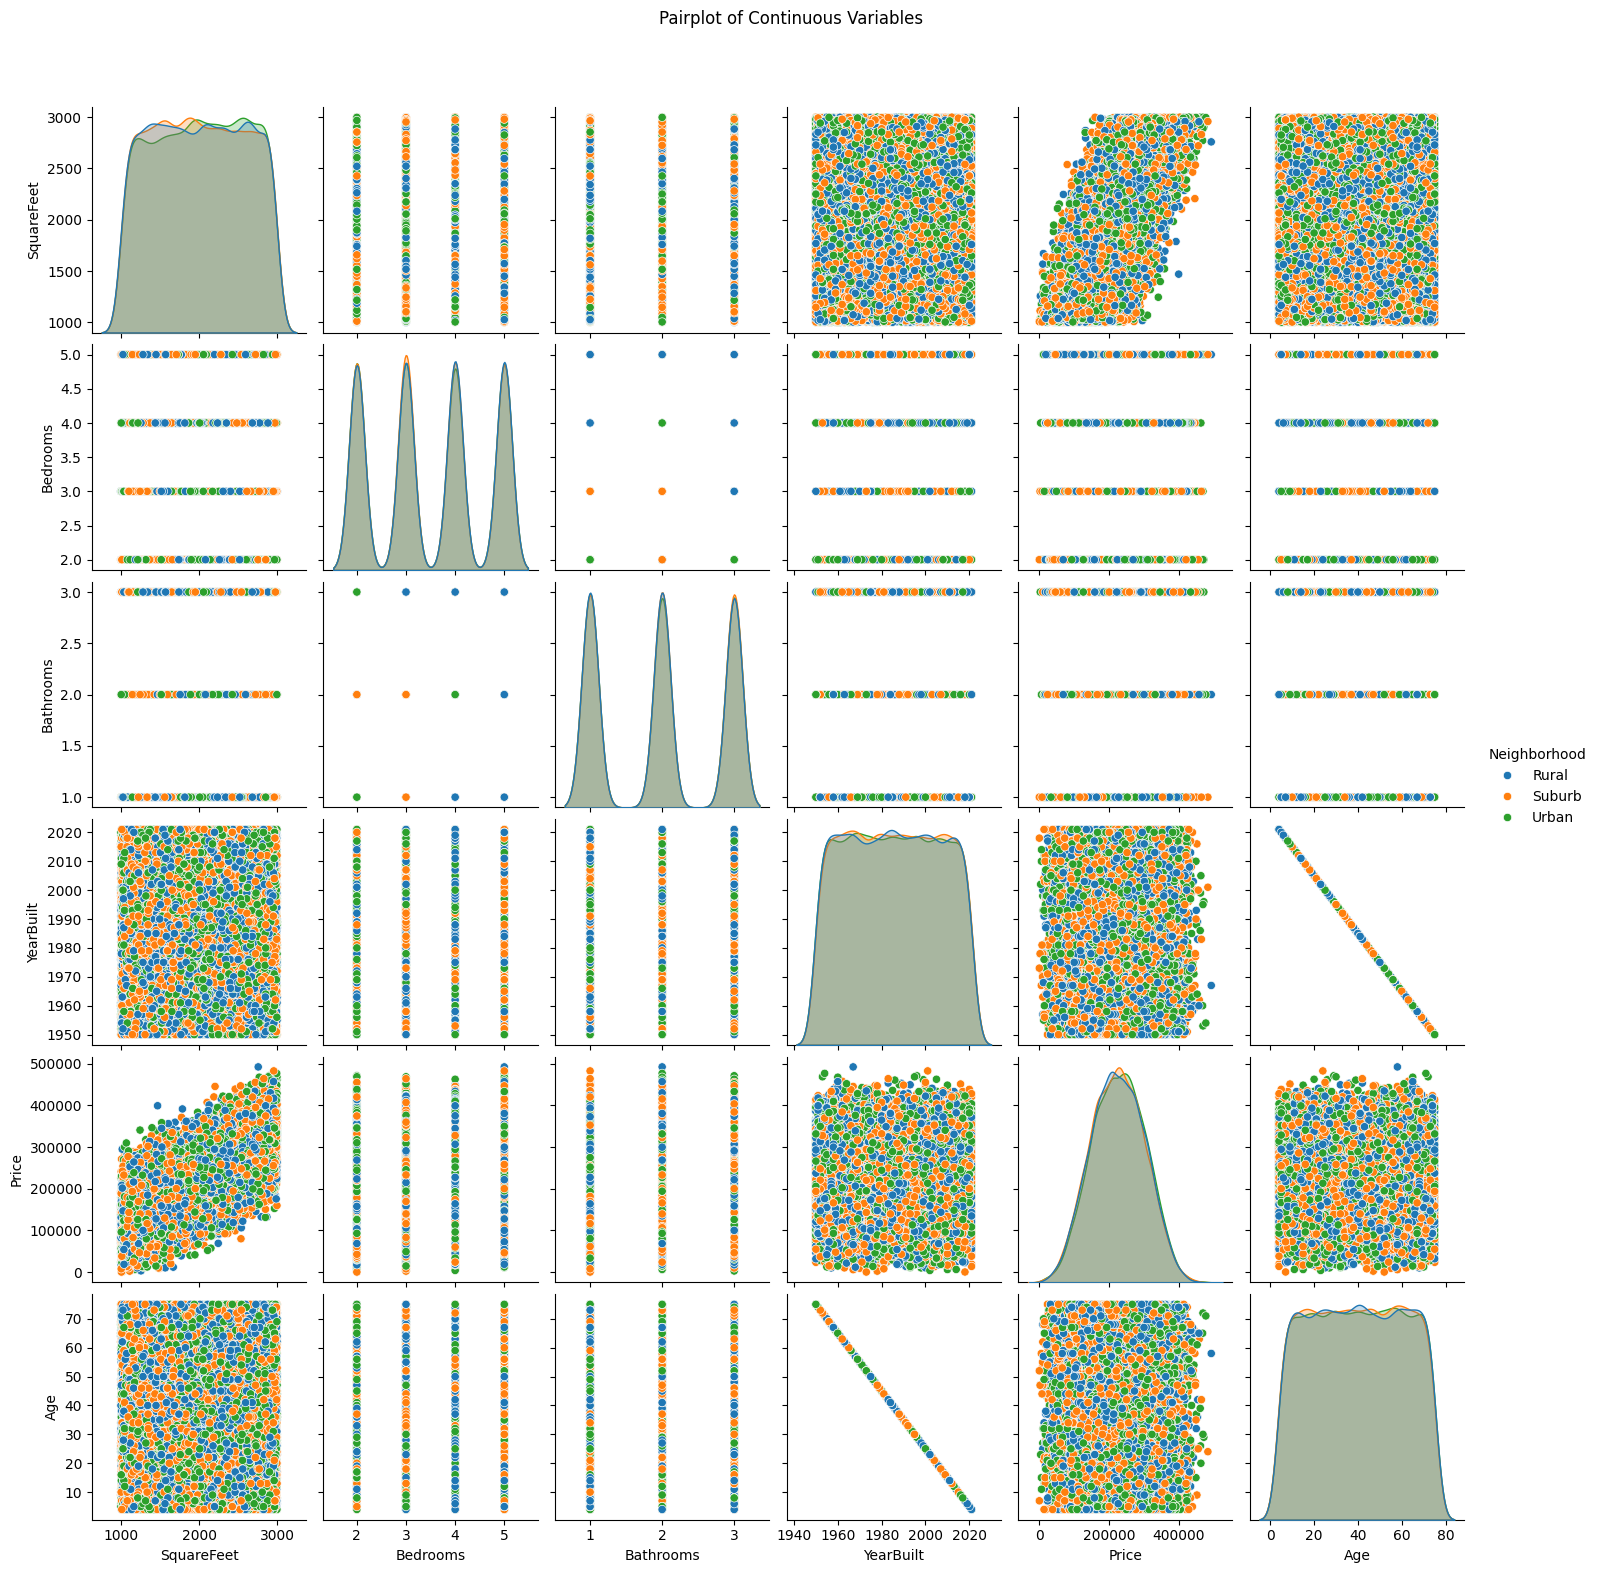

In [177]:
pairplot_columns = ['SquareFeet', 'Bedrooms', 'Bathrooms', 'YearBuilt',
       'Price','Age']
sns.pairplot(data,vars=pairplot_columns,hue='Neighborhood')
plt.suptitle('Pairplot of Continuous Variables',y=1.05)
plt.show()

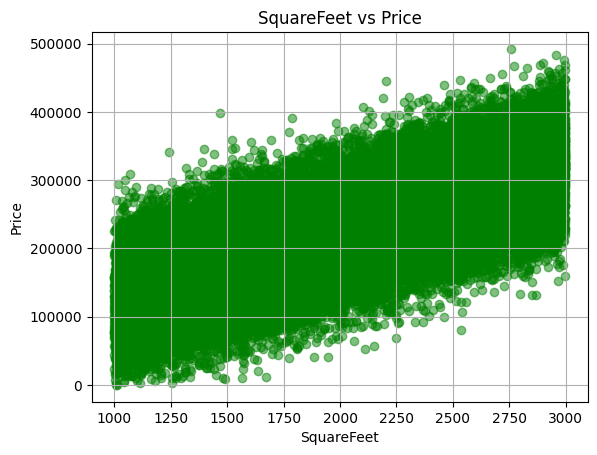

In [148]:
plt.scatter(data['SquareFeet'], data['Price'], alpha=0.5, color='green')
plt.title("SquareFeet vs Price")
plt.xlabel("SquareFeet")
plt.ylabel("Price")
plt.grid(True)
plt.show()


In [149]:
## one hot encoding the Neighborhood column
new_data = pd.get_dummies(data,columns=['Neighborhood'],drop_first=False)
new_data

,SquareFeet,Bedrooms,Bathrooms,YearBuilt,Price,Age,Neighborhood_Rural,Neighborhood_Suburb,Neighborhood_Urban
0,2126,4,1,1969,215355.283618,56,True,False,False
1,2459,3,2,1980,195014.221626,45,True,False,False
2,1860,2,1,1970,306891.012076,55,False,True,False
3,2294,2,1,1996,206786.787153,29,False,False,True
4,2130,5,2,2001,272436.239065,24,False,True,False
...,...,...,...,...,...,...,...,...,...
49995,1282,5,3,1975,100080.865895,50,True,False,False
49996,2854,2,2,1988,374507.656727,37,False,True,False
49997,2979,5,3,1962,384110.555590,63,False,True,False
49998,2596,5,2,1984,380512.685957,41,True,False,False


In [150]:
new_data.head()

,SquareFeet,Bedrooms,Bathrooms,YearBuilt,Price,Age,Neighborhood_Rural,Neighborhood_Suburb,Neighborhood_Urban
0,2126,4,1,1969,215355.283618,56,True,False,False
1,2459,3,2,1980,195014.221626,45,True,False,False
2,1860,2,1,1970,306891.012076,55,False,True,False
3,2294,2,1,1996,206786.787153,29,False,False,True
4,2130,5,2,2001,272436.239065,24,False,True,False


Text(0.5, 1.0, 'Correlation Matrix')

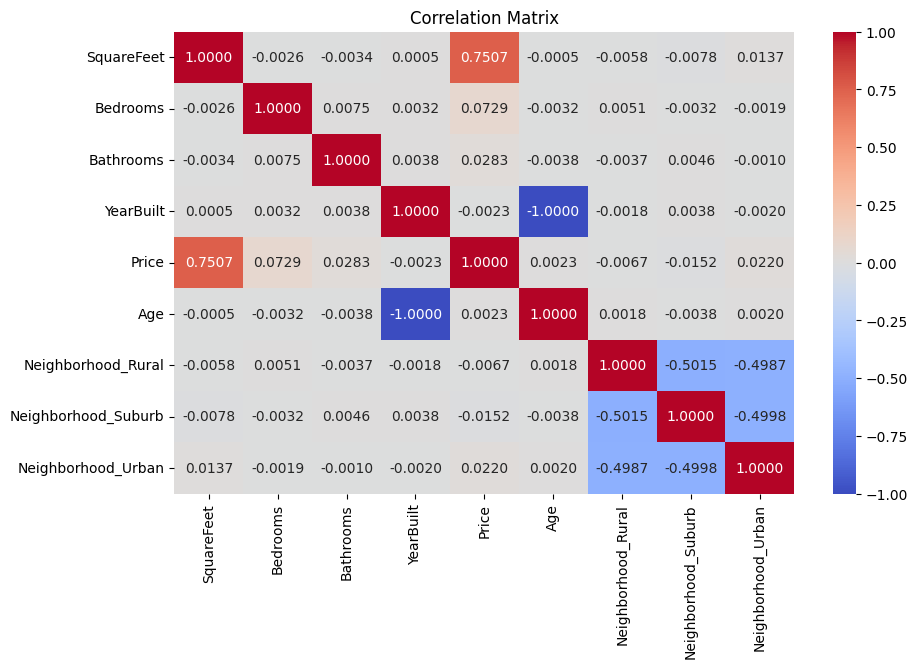

In [151]:
## Correlation Matrix
plt.figure(figsize=(10,6))
correlation_matrix = new_data.corr()
sns.heatmap(correlation_matrix,annot=True,cmap='coolwarm',fmt='.4f')
plt.title('Correlation Matrix')

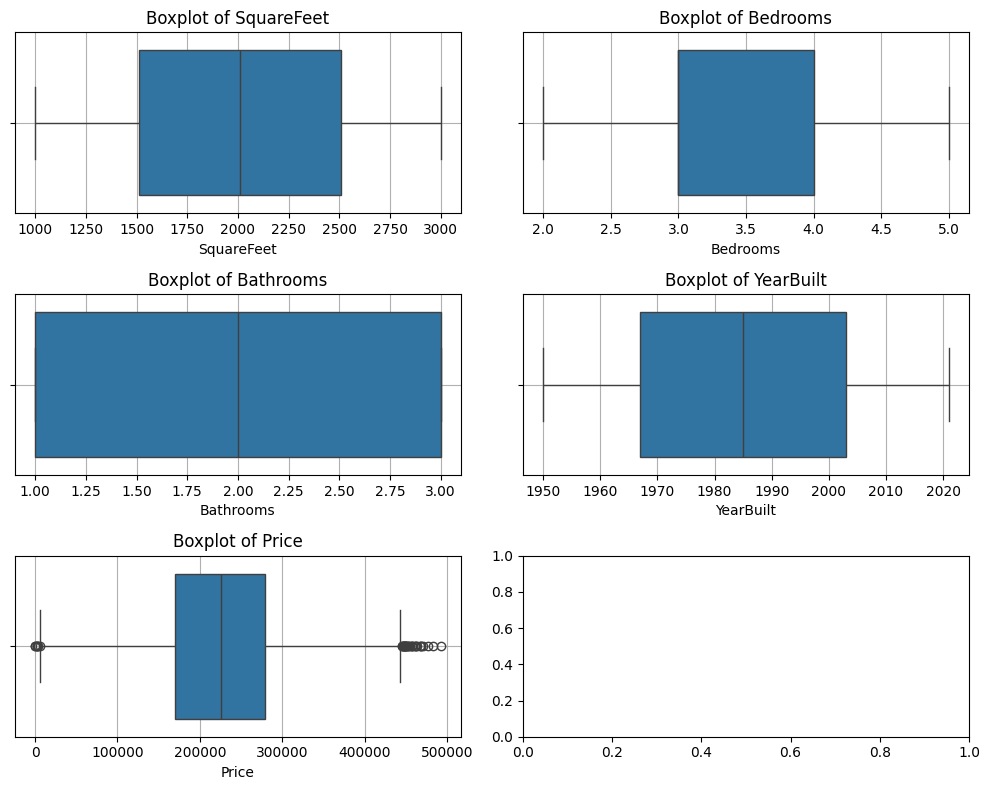

In [152]:
fig, ax = plt.subplots(nrows=3, ncols=2, figsize=(10, 8)) 
ax = ax.flatten() 

for i, col in enumerate(pairplot_columns):
    sns.boxplot(x=new_data[col], ax=ax[i])
    ax[i].set_title(f"Boxplot of {col}")
    ax[i].grid(True)

plt.tight_layout()
plt.show()



In [153]:
new_data.shape

(49978, 9)

In [154]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = new_data.drop("Price",axis=1)
y = new_data['Price']

In [155]:
X

,SquareFeet,Bedrooms,Bathrooms,YearBuilt,Age,Neighborhood_Rural,Neighborhood_Suburb,Neighborhood_Urban
0,2126,4,1,1969,56,True,False,False
1,2459,3,2,1980,45,True,False,False
2,1860,2,1,1970,55,False,True,False
3,2294,2,1,1996,29,False,False,True
4,2130,5,2,2001,24,False,True,False
...,...,...,...,...,...,...,...,...
49995,1282,5,3,1975,50,True,False,False
49996,2854,2,2,1988,37,False,True,False
49997,2979,5,3,1962,63,False,True,False
49998,2596,5,2,1984,41,True,False,False


In [156]:
y

0        215355.283618
1        195014.221626
2        306891.012076
3        206786.787153
4        272436.239065
             ...      
49995    100080.865895
49996    374507.656727
49997    384110.555590
49998    380512.685957
49999    221618.583218
Name: Price, Length: 49978, dtype: float64

In [157]:
## train test split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [158]:
X_train.shape

(39982, 8)

In [159]:
## Scaling the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [160]:
scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).flatten()
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1)).flatten()


In [161]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train_scaled, y_train_scaled)

LinearRegression()

In [162]:
y_pred_scaled = model.predict(X_test_scaled)

In [163]:
## transforming prediction to original scale
y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()

In [164]:
y_test

38298    339243.290088
44892    323235.930799
34675    248422.889866
39196    116974.660180
20267    169943.322343
             ...      
39090    292690.405831
34668     71992.816290
46574    237656.313683
16397    217680.469074
12597    392224.597499
Name: Price, Length: 9996, dtype: float64

In [165]:
y_pred

array([310477.17811102, 267323.24569664, 322772.26364217, ...,
       294516.44862007, 280047.47758262, 321318.28152045], shape=(9996,))

In [166]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

y_test_orig = scaler_y.inverse_transform(y_test_scaled.reshape(-1, 1)).flatten()
y_pred_orig = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()

print("Evaluation Metrics:")
print(f"MSE: {mean_squared_error(y_test_scaled, y_pred_scaled):.4f}")
print(f"MAE: {mean_absolute_error(y_test_scaled, y_pred_scaled):.4f}")
print(f"R² Score: {r2_score(y_test_scaled, y_pred_scaled):.4f}")

Evaluation Metrics:
MSE: 0.4236
MAE: 0.5199
R² Score: 0.5780


#### Interpreting Feature Importance

/tmp/ipykernel_60775/356431313.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x='Coefficient', y='Feature', palette='viridis')


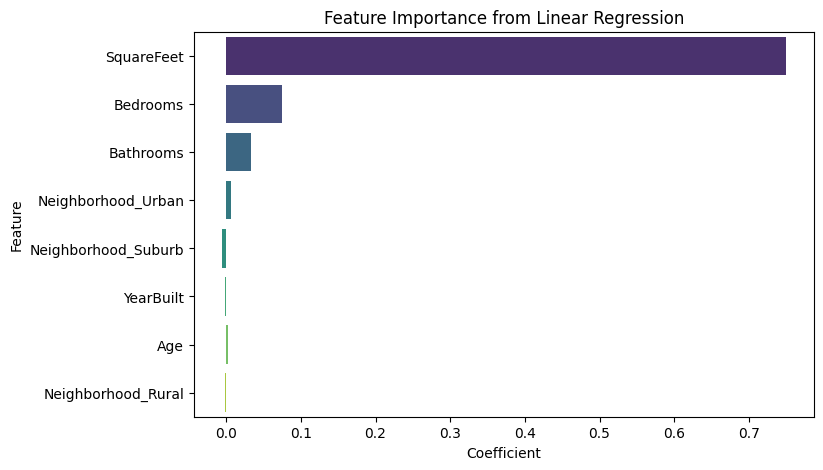

In [ ]:
coef = model.coef_
features = X.columns

importance_df = pd.DataFrame({'Feature': features, 'Coefficient': coef})
importance_df['Absolute'] = importance_df['Coefficient'].abs()
importance_df.sort_values('Absolute', ascending=False, inplace=True)

plt.figure(figsize=(8,5))
sns.barplot(data=importance_df, x='Coefficient', y='Feature', palette='viridis')
plt.title("Feature Importance from Linear Regression")
plt.show()

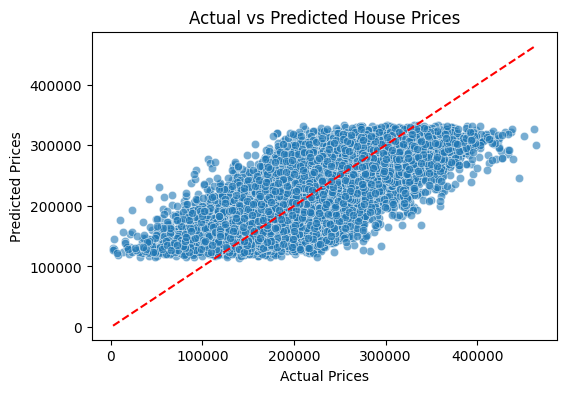

In [168]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # ideal line
plt.show()

#### Trying Polynomial Feature Engineering 

In [179]:
## Selecting 4 features
selected_features = ['SquareFeet', 'Bedrooms','Age', 'Bathrooms']

In [180]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]

X_train_poly = poly.fit_transform(X_train_selected)
X_test_poly = poly.transform(X_test_selected)


In [190]:
X_train_poly.shape

(39982, 14)

In [182]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_poly)
X_test_scaled = scaler.transform(X_test_poly)

In [183]:
poly_reg = LinearRegression()
poly_reg.fit(X_train_scaled,y_train)

LinearRegression()

In [184]:
y_pred = poly_reg.predict(X_test_scaled)

In [185]:
y_pred

array([311800.64180495, 266585.73213039, 322635.06779569, ...,
       296896.41145546, 279920.41700391, 320435.35561075], shape=(9996,))

In [186]:
y_test

38298    339243.290088
44892    323235.930799
34675    248422.889866
39196    116974.660180
20267    169943.322343
             ...      
39090    292690.405831
34668     71992.816290
46574    237656.313683
16397    217680.469074
12597    392224.597499
Name: Price, Length: 9996, dtype: float64

In [187]:
print("Evaluation Metrics:")
print(f"MSE: {mean_squared_error(y_test, y_pred):.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.4f}")
print(f"R² Score: {r2_score(y_test, y_pred):.4f}")

Evaluation Metrics:
MSE: 2447204219.9475
MAE: 39524.7512
R² Score: 0.5775
